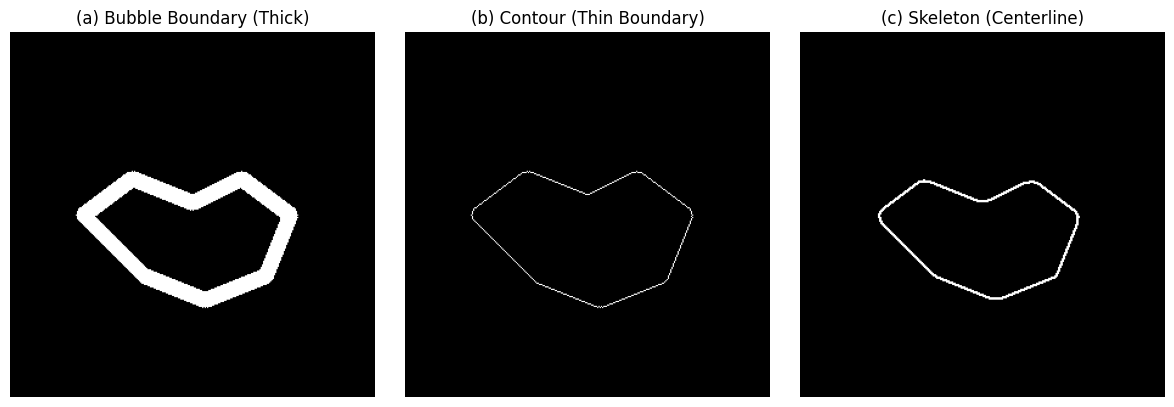

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize, thin

# =========================
# Create synthetic boundary (NOT filled)
# =========================
img = np.zeros((300, 300), dtype=np.uint8)

pts = np.array([
    [60,150], [100,120], [150,140], [190,120],
    [230,150], [210,200], [160,220], [110,200]
], np.int32)

pts = pts.reshape((-1,1,2))

# Thick boundary (same as segmentation output style)
cv2.polylines(img, [pts], isClosed=True, color=255, thickness=12)

# =========================
# (b) Contour — SAME as your pipeline
# =========================
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_img = np.zeros_like(img)
cv2.drawContours(contour_img, contours, -1, 255, 1)

# =========================
# (c) Skeleton — SAME as your pipeline
# =========================
skel = skeletonize(img.astype(bool)).astype(np.uint8) * 255
skel = thin(skel.astype(bool)).astype(np.uint8) * 255

# Clean small fragments (optional but good)
def remove_small_components(binary_img, min_size=20):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_img, connectivity=8)
    cleaned = np.zeros_like(binary_img)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            cleaned[labels == i] = 255
    return cleaned

skel = remove_small_components(skel, min_size=30)

# Thicken skeleton for visibility (ONLY for display)
kernel = np.ones((2,2), np.uint8)
skel_vis = cv2.dilate(skel, kernel)

# =========================
# Plot
# =========================
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# (a) Thick boundary
axs[0].imshow(img, cmap='gray')
axs[0].set_title("(a) Bubble Boundary (Thick)", fontsize=12)

# (b) Contour
axs[1].imshow(contour_img, cmap='gray')
axs[1].set_title("(b) Contour (Thin Boundary)", fontsize=12)

# (c) Skeleton
axs[2].imshow(skel_vis, cmap='gray')
axs[2].set_title("(c) Skeleton (Centerline)", fontsize=12)

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.savefig("conceptual_pipeline_consistent.png", dpi=300, bbox_inches='tight')
plt.show()

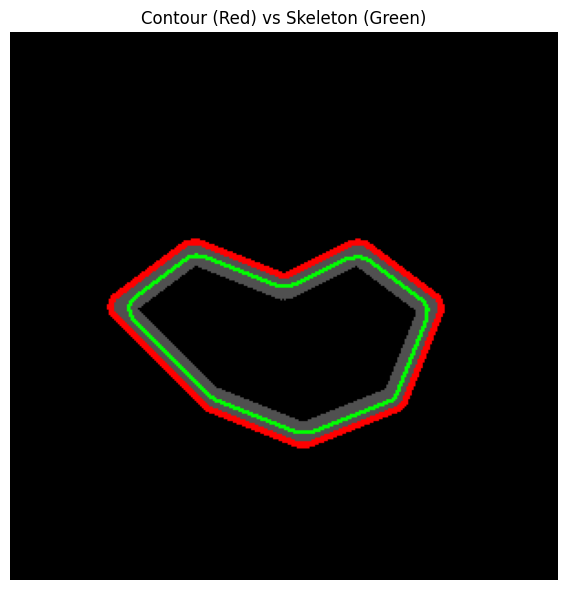

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize, thin

# =========================
# Create synthetic boundary
# =========================
img = np.zeros((300, 300), dtype=np.uint8)

pts = np.array([
    [60,150], [100,120], [150,140], [190,120],
    [230,150], [210,200], [160,220], [110,200]
], np.int32)

pts = pts.reshape((-1,1,2))

# Thick boundary
cv2.polylines(img, [pts], isClosed=True, color=255, thickness=12)

# =========================
# Contour (RED)
# =========================
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_img = np.zeros_like(img)
cv2.drawContours(contour_img, contours, -1, 255, 2)

# =========================
# Skeleton (GREEN)
# =========================
skel = skeletonize(img.astype(bool)).astype(np.uint8) * 255
skel = thin(skel.astype(bool)).astype(np.uint8) * 255

# Clean small fragments
def remove_small_components(binary_img, min_size=20):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_img, connectivity=8)
    cleaned = np.zeros_like(binary_img)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            cleaned[labels == i] = 255
    return cleaned

skel = remove_small_components(skel, min_size=30)

# Slight dilation for visibility
kernel = np.ones((2,2), np.uint8)
skel_vis = cv2.dilate(skel, kernel)

# =========================
# Overlay (SINGLE PANEL)
# =========================
overlay = np.zeros((300, 300, 3), dtype=np.uint8)

# Optional: show boundary faintly in gray
overlay[img > 0] = [80, 80, 80]

# Contour → RED
overlay[contour_img > 0] = [255, 0, 0]

# Skeleton → GREEN
overlay[skel_vis > 0] = [0, 255, 0]

# =========================
# Plot
# =========================
plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("Contour (Red) vs Skeleton (Green)")
plt.axis("off")
plt.tight_layout()
plt.savefig("overlay_single_panel.png", dpi=300, bbox_inches='tight')
plt.show()